In [1]:
import sys
import os
import re

import pandas as pd
import numpy as np
import scipy.sparse as sp

import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

nltk.download('stopwords')
nltk.download('wordnet')

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.append(src_path)

from metrics import *

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arianafernandez/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/arianafernandez/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# Load data
games = pd.read_csv("../data/cleansed/games_cleansed.csv")
ext = pd.read_csv("../data/cleansed/extended_games_cleansed_text.csv")
train = pd.read_csv("../data/cleansed/train_interactions_cleansed.csv")
test_all = pd.read_csv("../data/raw/test_interactions_in.csv")


Each user’s interaction history is split into two parts, a history set (test_in) and a holdout set (test_out). Interactions are randomly shuffled, ensuring that each part contains at least one item.

Users with only one interaction are treated as cold users, since their history cannot be divided.

In [3]:
def split_user_history(df, frac_hist=0.7, seed=42):
    """Split each user's interactions into history (test_in) and holdout (test_out).

    Users with only 1 interaction cannot be split, so they are returned as cold_users.
    """
    rng = np.random.default_rng(seed)

    hist_parts = []
    holdout_parts = []
    cold_users_parts = []

    for _, user_df in df.groupby("user_id"):
        idx = user_df.index.to_numpy()

        if len(idx) == 1:
            cold_users_parts.append(user_df)
            continue

        n_hist = max(1, int(len(idx) * frac_hist))
        shuffled_idx = rng.permutation(idx)

        hist_idx = shuffled_idx[:n_hist]
        holdout_idx = shuffled_idx[n_hist:]

        # Make sure holdout is not empty
        if len(holdout_idx) == 0:
            holdout_idx = hist_idx[-1:]
            hist_idx = hist_idx[:-1]

        hist_parts.append(df.loc[hist_idx])
        holdout_parts.append(df.loc[holdout_idx])

    empty_df = df.head(0)

    test_in = pd.concat(hist_parts) if hist_parts else empty_df
    test_out = pd.concat(holdout_parts) if holdout_parts else empty_df
    cold_users = pd.concat(cold_users_parts) if cold_users_parts else empty_df

    return test_in, test_out, cold_users


Top k recommendations are generated for each user from a score matrix, excluding items the user has already seen. For each user, the k highest scoring items are selected, sorted by score, and returned as a DataFrame with user, item, and rank.

In [4]:
def topk_recommendations(scores, k, seen_items, idx_to_user, idx_to_item):
    """Create top-k recommendations per user from a score matrix.

    Items in seen_items[u_idx] are filtered out (set to -inf).
    Returns a DataFrame with the columns user_id, item_id, rank.
    """
    recommendations = []
    n_users, _ = scores.shape

    for u_idx in range(n_users):
        user_scores = scores.getrow(u_idx).toarray().ravel()

        seen = seen_items.get(u_idx)
        if seen is not None:
            user_scores[list(seen)] = -np.inf

        top_k_idx = np.argpartition(-user_scores, k)[:k]
        top_k_idx = top_k_idx[np.argsort(-user_scores[top_k_idx])]

        for rank, item_idx in enumerate(top_k_idx, start=1):
            recommendations.append([
                idx_to_user[u_idx],
                idx_to_item[item_idx],
                rank
            ])

    return pd.DataFrame(
        recommendations,
        columns=["user_id", "item_id", "rank"]
    )

## Algorithm A: Content-based recommender

A left join is used to enrich the games data with information from ext. The duplicated columns, genres and tags, are then consolidated by keeping the version from games and removing the redundant ones.

In [5]:
# Merge metadata
merged = games.merge(
    ext,
    on=["item_id", "item_name"],
    how="left"
)

merged["genres"] = merged["genres_x"]
merged["tags"]   = merged["tags_x"]

merged = merged.drop(columns=["genres_x", "genres_y", "tags_x", "tags_y"], errors="ignore")

merged.head()

,item_id,item_name,publisher,specs,sentiment,release_date,short_description,about_the_game,detailed_description,reviews,categories,supported_languages,developers,publishers,genres,tags
0,0,Counter-Strike,valve,multi-player valve anti-cheat enabled,overwhelmingly positive,2000-11-01,play the world's number 1 online action game. ...,play the world's number 1 online action game. ...,play the world's number 1 online action game. ...,NaN,multi-player pvp online pvp shared/split scree...,english french german italian spanish - spain ...,valve,valve,action,action fps multiplayer shooter classic team-ba...
1,1,Rag Doll Kung Fu,mark healey,single-player multi-player,mixed,2005-10-12,a piece of steam history - the first ever non ...,a piece of steam history - the first ever non ...,a piece of steam history - the first ever non ...,NaN,single-player multi-player,english,mark healey,mark healey,indie,indie fighting multiplayer
2,2,Silo 2,nevercenter ltd. co.,NaN,mostly positive,2012-12-19,"silo is a focused, lightning-fast standalone 3...",note: this is a legacy version of silo which i...,note: this is a legacy version of silo which i...,NaN,NaN,english,nevercenter ltd. co.,nevercenter ltd. co.,animation & modeling,animation & modeling software
3,3,Call of Duty: World at War,activision,single-player multi-player co-op,very positive,2008-11-18,"call of duty is back, redefining war like you'...","call of duty is back, redefining war like you'...","call of duty is back, redefining war like you'...",NaN,single-player multi-player co-op,english french italian german spanish - spain,treyarch,activision,action,zombies world war ii fps action multiplayer sh...
4,4,3D-Coat V4.8,pilgway,steam cloud,very positive,2012-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,animation & modeling,animation & modeling


The BoW preprocessing described by Falk is applied to the text metadata. This includes normalization, stopword removal, lemmatization, and stemming. All text fields are then combined into a single document per item to build a suitable representation for TF IDF.

In [6]:
# Falk-style BoW preprocessing

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_falk(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()

    processed_tokens = []
    for tok in tokens:
        if tok in stop_words:
            continue

        tok = lemmatizer.lemmatize(tok)
        tok = stemmer.stem(tok)
        processed_tokens.append(tok)

    return " ".join(processed_tokens)

text_cols = [
    "genres",
    "tags",
    "categories",
    "short_description",
]

for col in text_cols:
    merged[col] = merged[col].fillna("").astype(str).apply(preprocess_falk)

merged["text_falk"] = merged[text_cols].agg(" ".join, axis=1)

merged[["item_id", "item_name", "text_falk"]].head()


,item_id,item_name,text_falk
0,0,Counter-Strike,action action fp multiplay shooter classic tea...
1,1,Rag Doll Kung Fu,indi indi fight multiplay singl player multi p...
2,2,Silo 2,anim model anim model softwar silo focus ligh...
3,3,Call of Duty: World at War,action zombi world war ii fp action multiplay ...
4,4,3D-Coat V4.8,anim model anim model


Each item is assigned a numeric index so it can be used in matrices. Mappings are stored to convert from item IDs to indices and back.

In [7]:
item_ids = merged["item_id"].tolist()

item_to_idx = {}
for i in range(len(item_ids)):
    item_to_idx[item_ids[i]] = i

idx_to_item = np.array(item_ids)
n_items = len(item_ids)


Rows with unknown items are removed, and each item_id is replaced by its numeric index so that the train and test data match the items used by the model.

In [8]:
train_idx = train[train["item_id"].isin(item_to_idx)].copy()
train_idx["item_id"] = train_idx["item_id"].map(item_to_idx)

test_idx = test_all[test_all["item_id"].isin(item_to_idx)].copy()
test_idx["item_id"] = test_idx["item_id"].map(item_to_idx)

Each user’s history is split into a known part (test_in) and an evaluation part (test_out). Cold start users are identified, a numeric index is assigned to each user, and the items already seen by each user are stored so they can be filtered out during recommendation.

In [9]:
# Split test into test_in, test_out and track cold users
test_in, test_out, cold_users = split_user_history(test_idx, frac_hist=0.7, seed=42)

print("Evaluable users:", test_out["user_id"].nunique())
print("Cold-start users:", cold_users["user_id"].nunique())

users_test = test_in["user_id"].unique().tolist()
n_users_test = len(users_test)

# User index mapping for test
user_to_idx_test = {}
idx_to_user_test = {}
for i in range(n_users_test):
    u = users_test[i]
    user_to_idx_test[u] = i
    idx_to_user_test[i] = u

test_in["user_index"] = test_in["user_id"].map(user_to_idx_test)
assert test_in["user_index"].notna().all()

# Items seen in test_in 
seen_items_test = {}
for row in test_in[["user_index", "item_id"]].itertuples(index=False):
    u_idx, item_id = row
    if u_idx not in seen_items_test:
        seen_items_test[u_idx] = set()
    seen_items_test[u_idx].add(item_id)


Evaluable users: 12464
Cold-start users: 1115


A TF IDF item matrix is built from the preprocessed text and normalized using L2.

In [10]:
# TF-IDF item matrix
vectorizer = TfidfVectorizer(
    max_features=20000,
    min_df=5,
    max_df=0.8,
    stop_words="english",
)

X_items_tfidf = vectorizer.fit_transform(merged["text_falk"])
I_A = normalize(X_items_tfidf, norm="l2")

The TF IDF matrix is converted into a DataFrame only to inspect its shape and structure, such as rows and features, not to use it in the model.

In [11]:
tfidf_df = pd.DataFrame(X_items_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head()

,abandon,abduct,abil,abl,aboard,absolut,absorb,abstract,abyss,academi,...,young,yuri,zani,zelda,zen,zero,zombi,zone,zoo,zoom
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.104628,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


A numeric index is created for each user in the training set and added to the DataFrame so the model matrices can be built.

In [12]:
# User index mapping for train
train_A = train_idx.copy()

users_train = train_A["user_id"].unique().tolist()

user_to_idx_train = {}
for i in range(len(users_train)):
    user_to_idx_train[users_train[i]] = i

train_A["user_index"] = train_A["user_id"].map(user_to_idx_train)

The binary user–item training matrix is built and used to aggregate the TF-IDF vectors of the items each user has interacted with, producing a normalized user profile for each user.

In [13]:
# Build train user-item matrix for content profiles
n_users = len(users_train)

values = np.ones(len(train_A), dtype=np.float32)
row_idx = train_A["user_index"].values
col_idx = train_A["item_id"].values

X_ui_train_A = sp.csr_matrix(
    (values, (row_idx, col_idx)),
    shape=(n_users, n_items)
)

U_train = normalize(X_ui_train_A @ X_items_tfidf, norm="l2")


In [14]:
# Build test user profiles from test_in
n_users_test = len(users_test)

values = np.ones(len(test_in), dtype=np.float32)
row_idx = test_in["user_index"].values
col_idx = test_in["item_id"].values

X_ui_test = sp.csr_matrix(
    (values, (row_idx, col_idx)),
    shape=(n_users_test, n_items)
)

U_test = normalize(X_ui_test @ X_items_tfidf, norm="l2")


Cosine similarity scores are computed between user profiles and items. Top 20 recommendations are generated by filtering out seen items, and the model is evaluated using Recall@20 and NDCG@20 on the holdout set test_out.

In [15]:
scores_A = (U_test @ I_A.T).tocsr() #cosine similarity

df_recos_A = topk_recommendations(
    scores_A,
    20,
    seen_items_test,
    idx_to_user_test,
    idx_to_item
)

recall_A = calculate_calibrated_recall(df_recos_A, 20, test_out)
ndcg_A = calculate_ndcg(df_recos_A, 20, test_out)

print("Recall@20:", recall_A)
print("NDCG@20:", ndcg_A)

Recall@20: 0.08190098577212226
NDCG@20: 0.05416091294526842


Item coverage at 20 is computed as the proportion of the full catalog that appears at least once in the top 20 recommendations.

In [16]:
k = 20

item_cov_A = calculate_item_coverage(
    df_recos_A,
    k=k,
    n_items=n_items
)

print("Item coverage@20:", item_cov_A)

Item coverage@20: 0.2807696820368415


## Algorithm B: Collaborative-based recommender

A binary user item training matrix is built for the collaborative model, where each entry indicates whether a user has interacted with an item.

In [17]:
train_B = train_idx.copy()
train_B["user_index"] = train_B["user_id"].map(user_to_idx_train)
assert train_B["user_index"].notna().all()

values = np.ones(len(train_B), dtype=np.float32)

row_indices = train_B["user_index"].values

col_indices = train_B["item_id"].values

X_ui_train_B = sp.csr_matrix(
    (values, (row_indices, col_indices)),
    shape=(n_users, n_items)
)
assert X_ui_train_B.shape == (n_users, n_items)


A small portion of the user item matrix, including the first users and items, is shown only for inspection and visual verification of its structure.

In [18]:
pd.DataFrame(
    X_ui_train_B[:5, :10].toarray(),
    index=[f"user_{i}" for i in range(5)],
    columns=[f"item_{j}" for j in range(10)]
)

,item_0,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9
user_0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
user_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
user_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
user_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
user_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Item to item cosine similarity is computed from the user item matrix by normalizing dot products with item norms and setting self similarity to zero.

In [19]:
def item_cosine_similarity(X):
    """Item-item cosine similarity from a (user x item) interaction matrix."""
    X = X.tocsr()

    norms = np.sqrt(X.power(2).sum(axis=0)).A1
    norms[norms == 0] = 1.0

    S = (X.T @ X).tocsr()

    # normalize to cosine similarity
    inv_norms = sp.diags(1.0 / norms)
    S = inv_norms @ S @ inv_norms

    S.setdiag(0)
    S.eliminate_zeros()

    return S


For each row of the similarity matrix, only the top k highest values are kept, representing the most similar neighbors, and the rest are removed to obtain a sparse top k matrix.

In [20]:
def topk_on_rows(sim_matrix, k):
    """Keep only top-k values per row in a sparse similarity matrix."""
    sim_matrix = sim_matrix.tolil()

    for i in range(sim_matrix.shape[0]):
        values = sim_matrix.data[i]
        indices = sim_matrix.rows[i]

        if len(values) > k:
            top_idx = np.argpartition(values, -k)[-k:]
            sim_matrix.data[i] = list(np.array(values)[top_idx])
            sim_matrix.rows[i] = list(np.array(indices)[top_idx])

    return sim_matrix.tocsr()


ItemKNN recommendations are computed using top 50 item to item similarities. Top 20 recommendations are generated for each user by filtering out seen items, and the model is evaluated using Recall@20 and NDCG@20 on the holdout set.

In [21]:
S_items = item_cosine_similarity(X_ui_train_B)
S_knn = topk_on_rows(S_items, k=50)

scores_B = (X_ui_test @ S_knn).tocsr()
df_recos_B = topk_recommendations(
    scores_B,
    20,
    seen_items_test,
    idx_to_user_test,
    idx_to_item
)

recall_B = calculate_calibrated_recall(df_recos_B, 20, test_out)
ndcg_B = calculate_ndcg(df_recos_B, 20, test_out)

print("Recall@20:", recall_B)
print("NDCG@20:", ndcg_B)

Recall@20: 0.3102073321416392
NDCG@20: 0.25721606796854535


Item coverage at 20 is computed for the collaborative model as the proportion of the catalog that appears at least once in the top 20 recommendations.

In [22]:
k = 20

item_cov_B = calculate_item_coverage(
    df_recos_B,
    k=k,
    n_items=n_items
)

print("Item coverage@20:", item_cov_B)

Item coverage@20: 0.17423442449841606


Intra list similarity is computed for all models using the same content based item similarity, ensuring a consistent comparison of diversity at the content level.

In [23]:
# Diversity uses the same content-based item similarity for all models
item_similarity_matrix_A = (I_A @ I_A.T).toarray()

ILS_A = calculate_intra_list_sim(df_recos_A, 20, item_similarity_matrix_A)
ILS_B = calculate_intra_list_sim(df_recos_B, 20, item_similarity_matrix_A)

print("ILS_A@20:", ILS_A)
print("ILS_B@20:", ILS_B)

ILS_A@20: 0.4773117308194529
ILS_B@20: 0.2534416751949361


## Algorithm E: MMR Reranking

MMR reranking is applied by starting from the highest scoring items and selecting the top N items step by step. At each step, relevance and diversity are balanced by penalizing items that are too similar to those already selected.

In [24]:
def mmr_rerank(scores_row, item_sim, seen_items, alpha, N=20, M=200):
    """Rerank items using MMR."""
    candidates = []

    # Collect candidate items and their scores
    for item_id in range(len(scores_row)):
        if item_id in seen_items:
            continue
        candidates.append((item_id, scores_row[item_id]))

    # Sort candidates by relevance score
    candidates.sort(key=lambda x: x[1], reverse=True)

    # Keep only the top-M candidates
    C = []
    for item_id, _ in candidates[:M]:
        C.append(item_id)

    R = []

    # Select items one by one using MMR
    while len(R) < N and C:
        best_item = None
        best_score = None

        for i in C:
            relevance = scores_row[i]

            if not R:
                score = relevance
            else:
                max_sim = 0.0
                for j in R:
                    sim = item_sim[i][j]
                    if sim > max_sim:
                        max_sim = sim
                # Balance relevance and diversity
                score = alpha * relevance - (1 - alpha) * max_sim

            if best_score is None or score > best_score:
                best_score = score
                best_item = i

        R.append(best_item)
        C.remove(best_item)

    return R


Generate top-k recommendations for all users using MMR reranking.

In [25]:
def mmr_recommend_all_users(scores_csr, seen_dict, idx_to_user, alpha, k=20, M=200):
    """Generate MMR recommendations for all users."""
    recs = []
    for u_idx in range(scores_csr.shape[0]):
        user_id = idx_to_user[u_idx]
        seen = seen_dict.get(u_idx, set())

        # Get scores for the current user
        scores_row = scores_csr.getrow(u_idx).toarray().ravel() # flatten
        ranked_items = mmr_rerank(scores_row, item_similarity_matrix_A, seen, alpha, N=k, M=M)

        # Apply MMR reranking to balance relevance and diversity
        for rank, item_idx in enumerate(ranked_items, start=1):
            recs.append([user_id, item_idx, rank])

    return pd.DataFrame(recs, columns=["user_id", "item_id", "rank"])


Evaluate MMR reranking with different alpha values to analyze the accuracy–diversity trade-off.

In [26]:
alphas = [0.3, 0.5, 0.7, 0.9]
rows = []

for a in alphas:
    df_recos = mmr_recommend_all_users(scores_B, seen_items_test, idx_to_user_test, a, k=20, M=200)

    rows.append([
        a,
        calculate_calibrated_recall(df_recos, 20, test_out),
        calculate_ndcg(df_recos, 20, test_out),
        calculate_intra_list_sim(df_recos, 20, item_similarity_matrix_A),
        calculate_item_coverage(df_recos, k=20, n_items=n_items),
    ])

df_mmr_grid = pd.DataFrame(rows, columns=["alpha","Recall@20","NDCG@20","ILS@20","ItemCoverage@20"])


In [27]:
df_mmr_grid

,alpha,Recall@20,NDCG@20,ILS@20,ItemCoverage@20
0,0.3,0.271274,0.234706,0.203447,0.235480
1,0.5,0.297485,0.249415,0.231203,0.209668
2,0.7,0.306107,0.254890,0.243122,0.196058
3,0.9,0.309553,0.256832,0.250490,0.180922


## Graph

Plot accuracy and diversity metrics for different MMR alpha values.

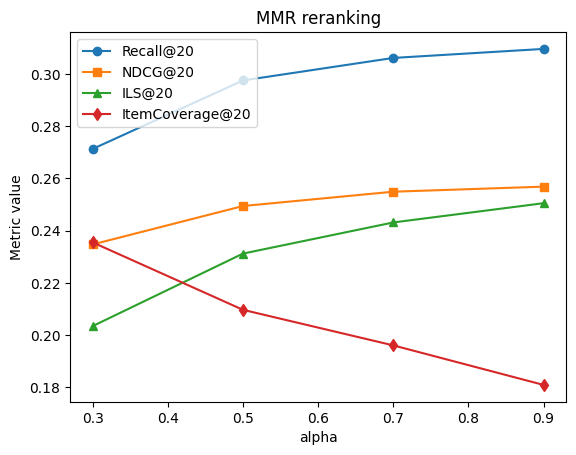

In [28]:
x = df_mmr_grid["alpha"]

plt.figure()
plt.plot(x, df_mmr_grid["Recall@20"], marker="o", label="Recall@20")
plt.plot(x, df_mmr_grid["NDCG@20"], marker="s", label="NDCG@20")
plt.plot(x, df_mmr_grid["ILS@20"], marker="^", label="ILS@20")
plt.plot(x, df_mmr_grid["ItemCoverage@20"], marker="d", label="ItemCoverage@20")

plt.xlabel("alpha")
plt.ylabel("Metric value")
plt.title("MMR reranking")
plt.legend()
plt.show()


In [33]:
# Generates CSV for submission

k = 20
alpha = 0.7
M = 200

# User mapping for the full test
users_test_full = test_idx["user_id"].unique()
user_to_idx = {u: i for i, u in enumerate(users_test_full)}
idx_to_user = {i: u for u, i in user_to_idx.items()}

test_full = test_idx.copy()
test_full["user_index"] = test_full["user_id"].map(user_to_idx)

# Seen items per user
seen_full = test_full.groupby("user_index")["item_id"].apply(set).to_dict()

# Full test user-item matrix
X_ui_test_full = sp.csr_matrix(
    (np.ones(len(test_full), dtype=np.float32),
     (test_full["user_index"].values, test_full["item_id"].values)),
    shape=(len(users_test_full), n_items)
)

# CF scores for all users
scores_B_full = (X_ui_test_full @ S_knn).tocsr()

# MMR and CSV
df_recos_full = mmr_recommend_all_users(scores_B_full, seen_full, idx_to_user, alpha, k=k, M=M)
df_recos_full["item_id"] = df_recos_full["item_id"].map(lambda i: int(idx_to_item[i]))

df_submission = df_recos_full[["user_id", "item_id"]]
df_submission.to_csv("submission.csv", index=False)
